In [7]:
%load_ext autoreload
%autoreload 2

# Imports
import os
import sys
from IPython.display import display

# Ensure project root is on sys.path so we can import from py_scripts
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from py_scripts.music_utils import parse_files

# Configuration
FILTER_ZERO_DURATION = True
ADJUST_FRACTIONAL_DURATION = True
PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'
SHOW_MEASURE_LINES = True   # draw red vertical lines at measure starts
DISPLAY_PREVIEW = True
PREVIEW_ROWS = 20
CLEANUP_REMOTE = True       # if source is a URL, delete temp file after parsing
RETURN_PLOTS = False        # include plot objects in results under 'plot'

# List of file sources (URLs or local paths)
FILE_SOURCES = [
    'https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml',
    'https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn'
]

# Parse and visualize
results, dfs_by_name, df_processed = parse_files(
    FILE_SOURCES,
    filter_zero_duration=FILTER_ZERO_DURATION,
    adjust_fractional_duration=ADJUST_FRACTIONAL_DURATION,
    backend=PLOTTING_BACKEND,
    show_measure_lines=SHOW_MEASURE_LINES,
    display_preview=DISPLAY_PREVIEW,
    preview_rows=PREVIEW_ROWS,
    cleanup_remote=CLEANUP_REMOTE,
    return_plots=RETURN_PLOTS,
)

# Show quick summary
print('Parsed DataFrames:')
for item in results:
    name = item['name']
    df = item['df']
    pos_dur = df.loc[df['Duration'] > 0, 'Duration'] if 'Duration' in df.columns else None
    min_dur_str = str(float(pos_dur.min())) if pos_dur is not None and len(pos_dur) > 0 else 'n/a'
    print(f"- {name}: rows={len(df)}, unique_pitches={df['MIDI'].nunique()}, min_duration={min_dur_str}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Processing: PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml -> 00_prjode_jos0302_com_1_5_missadapac_002_00006


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI
0,1,0.0,0.0,8.0,G3,55
1,1,8.0,8.0,4.0,F3,53
2,2,0.0,12.0,8.0,G4,67
3,2,0.0,12.0,3.0,G3,55
4,2,3.0,15.0,1.0,A3,57
5,2,4.0,16.0,2.0,B-3,58
6,2,6.0,18.0,2.0,G3,55
7,2,8.0,20.0,4.0,F4,65
8,2,8.0,20.0,4.0,A3,57
9,3,0.0,24.0,3.0,G4,67


Rows: 797, unique pitches: 24
Processing: wtc1f04.krn -> 01_wtc1f04


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI
0,1,0.0,0.0,4.0,C#3,49
1,2,0.0,4.0,2.0,B#2,48
2,2,2.0,6.0,2.0,E3,52
3,3,0.0,8.0,4.0,D#3,51
4,4,0.0,12.0,4.0,G#3,56
5,4,0.0,12.0,1.0,C#3,49
6,4,1.0,13.0,1.0,D#3,51
7,4,2.0,14.0,2.0,E3,52
8,5,0.0,16.0,2.0,F##3,55
9,5,0.0,16.0,1.0,E3,52


Rows: 1429, unique pitches: 45
Parsed DataFrames:
- 00_prjode_jos0302_com_1_5_missadapac_002_00006: rows=797, unique_pitches=24, min_duration=0.5
- 01_wtc1f04: rows=1429, unique_pitches=45, min_duration=0.5


In [8]:
list(dfs_by_name)


['00_prjode_jos0302_com_1_5_missadapac_002_00006', '01_wtc1f04']

In [10]:
df_processed = dfs_by_name[list(dfs_by_name)[0]]
df_processed.head()

,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI
0,1,0.0,0.0,8.0,G3,55
1,1,8.0,8.0,4.0,F3,53
2,2,0.0,12.0,8.0,G4,67
3,2,0.0,12.0,3.0,G3,55
4,2,3.0,15.0,1.0,A3,57


In [11]:
# Binary conversion and visualization (refactored to py_scripts)
import numpy as np
import pandas as pd
from py_scripts.music_utils import create_binary_matrix, plot_binary_matrix

# Configuration
BINARY_RESOLUTION_METHOD = 'auto'   # 'auto' | 'manual' | 'standard'
BINARY_MANUAL_RES = None            # e.g., 0.5 when using 'manual'
Y_AXIS_MODE = 'full'              # 'full' | 'minmax' | 'chroma'
Y_AXIS_MIN = None                   # optional int when Y_AXIS_MODE=='minmax'
Y_AXIS_MAX = None                   # optional int when Y_AXIS_MODE=='minmax'

# Build binary matrix
binary_matrix_df, meta = create_binary_matrix(
    df_processed,
    resolution_method=BINARY_RESOLUTION_METHOD,
    manual_resolution=BINARY_MANUAL_RES,
    y_mode=Y_AXIS_MODE,
    midi_low=Y_AXIS_MIN,
    midi_high=Y_AXIS_MAX,
)

# Provide both orientations for convenience
binary_matrix_df_data = binary_matrix_df
binary_matrix_df_view = np.flipud(binary_matrix_df)

print(f"Binary matrix shape: {binary_matrix_df.shape}")
print(f"Resolution: {meta['resolution']}, columns: {meta['num_cols']}, y_mode: {meta['y_mode']}")

# Plot using the same backend as parsing cell (if defined), else default to 'plt'
try:
    backend_to_use = PLOTTING_BACKEND
except NameError:
    backend_to_use = 'plt'

# If measure offsets were computed earlier, you can pass them here.
# In this notebook, measure offsets are inside `results` items if needed; we default to None
plot_binary_matrix(
    binary_matrix_df,
    meta,
    backend=backend_to_use,
    measure_offsets=None,
    show_measure_lines=True,
    show=True,
)


Binary matrix shape: (128, 1360)
Resolution: 0.5, columns: 1360, y_mode: full


figure(id='p1531', ...)

In [12]:
print(binary_matrix_df_view)
print(binary_matrix_df_data)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [7]:
# Refactored: import notation utilities from py_scripts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from py_scripts.music_utils import (
    parse_prototype_notation,
    parse_notation,
)

# Example (prototype) to maintain backward compatibility in later cells:
notation = "C4:0:1, D4:1:1, E4:2:1, F4:3:1.5"
prototype_df = parse_prototype_notation(notation)
print("Parsed Prototype DataFrame:")
print(prototype_df)


Parsed Prototype DataFrame:
   MIDI  Global Onset  Duration
0    60           0.0       1.0
1    62           1.0       1.0
2    64           2.0       1.0
3    65           3.0       1.5


### Prototype notation and supported input formats

You can parse short motifs or full texts using `parse_notation(text, syntax)`. The `syntax` must be one of: `prototype`, `tinynotation`, `humdrum`, `abc`, `lilypond`.

- **prototype**: custom `NOTE:ONSET:DURATION` tokens. Separators: comma, semicolon, or newline.
  - Example:
    - `C4:0:1, D4:1:1, E4:2:1, F#4:3:0.5`
    - Multi-line:
      `A3:0:2; C4:2:1\nE4:3:1.5`
- **tinynotation** (music21 TinyNotation): prepend meter inside the string if needed.
  - Example: `"3/4 c4 d8 f g16 a g f#"`
- **humdrum** (`**kern`): paste the entire Humdrum text.
  - Example (very short):
    ```
    **kern
    *M4/4
    =1
    4c
    4d
    4e
    4f
    *-
    ```
- **abc**: paste full ABC with headers and body.
  - Example:
    ```
    X:1
    T:Example
    M:4/4
    L:1/4
    K:C
    C D E F
    ```
- **lilypond**: paste a LilyPond snippet (requires LilyPond installed for full support).
  - Example:
    ```
    \relative c' { \time 4/4 c4 d e f }
    ```

The function returns a DataFrame with columns `MIDI`, `Global Onset`, `Duration`. When called with `return_meta=True`, it also returns a metadata dict, including `parsed_format`.



In [41]:
# Syntax selector and parsing according to format guidelines

# Choose one: 'prototype' | 'tinynotation' | 'humdrum' | 'abc' | 'lilypond'
NOTATION_SYNTAX = 'prototype'

# Provide notation text according to the chosen syntax:
# - prototype: NOTE:ONSET:DURATION tokens, separated by comma/semicolon/newline
# - tinynotation: music21 TinyNotation, e.g., "3/4 c4 d8 f g16 a g f#"
# - humdrum: paste full **kern/**humdrum text
# - abc: paste full ABC text (headers + body)
# - lilypond: paste LilyPond snippet
NOTATION_TEXT = """C4:0:1, D4:1:1, E4:2:1, F4:3:1.5"""

df_notation, meta = parse_notation(NOTATION_TEXT, NOTATION_SYNTAX, return_meta=True)
parsed_format = meta.get('parsed_format')
print(f"Parsed format: {parsed_format}")
print("Parsed notation preview:")
display(df_notation.head(20))

# Quick summary
if 'Duration' in df_notation.columns:
    pos_dur = df_notation.loc[df_notation['Duration'] > 0, 'Duration']
    min_dur_str = str(float(pos_dur.min())) if len(pos_dur) > 0 else "n/a"
else:
    min_dur_str = "n/a"

print(f"Summary: rows={len(df_notation)}, unique_pitches={df_notation['MIDI'].nunique()}, min_duration={min_dur_str}")



Parsed format: prototype
Parsed notation preview:


,MIDI,Global Onset,Duration
0,60,0.0,1.0
1,62,1.0,1.0
2,64,2.0,1.0
3,65,3.0,1.5


Summary: rows=4, unique_pitches=4, min_duration=1.0


In [53]:
# Refactored: use functions from py_scripts to build and plot prototype matrix
import numpy as np
from py_scripts.music_utils import create_prototype_binary_matrix, plot_prototype_binary_matrix

# Build prototype binary matrix
binary_matrix_prototype, proto_meta = create_prototype_binary_matrix(prototype_df, resolution=0.5)
binary_matrix_prototype_data = binary_matrix_prototype
binary_matrix_prototype_view = np.flipud(binary_matrix_prototype)
print("\nPrototype Binary Matrix shape:", binary_matrix_prototype.shape)
print("Resolution:", proto_meta['resolution'], "columns:", proto_meta['num_cols'])

# Plot using selected backend
try:
    backend_to_use = PLOTTING_BACKEND
except NameError:
    backend_to_use = 'plt'


plot_prototype_binary_matrix(
    binary_matrix_prototype,
    proto_meta,
    backend=backend_to_use,
    measure_offsets=None,
    show_measure_lines=True,
    show=True,
)


Prototype Binary Matrix shape: (6, 9)
Resolution: 0.5 columns: 9


figure(id='p1247', ...)

In [9]:
print(binary_matrix_prototype_view)

[[0 0 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]]


In [10]:

import numpy as np
import ipywidgets as widgets
from IPython.display import display
from IPython import get_ipython
from functools import partial

try:
    from ipycanvas import Canvas
except ImportError:
    Canvas = None


def binary_matrix_designer(rows=8, cols=8, max_size=64, prototype=None, cell_size=28, flip_vertical=True):
    # Interactive editor for binary matrices with toggle grid and free-draw canvas.
    if Canvas is None:
        raise ImportError("ipycanvas is required for free draw mode. Install it with `pip install ipycanvas`.")
    rows = int(rows)
    cols = int(cols)
    max_size = int(max_size)
    ip = get_ipython()
    user_ns = ip.user_ns if ip else {}
    message = widgets.Output(layout=widgets.Layout(min_height='24px'))
    output = widgets.Output()
    grid_container = widgets.Box(layout=widgets.Layout(justify_content='center'))
    canvas_widget = Canvas(width=max(1, cols * cell_size), height=max(1, rows * cell_size), layout=widgets.Layout(border='1px solid #ccc'))
    rows_input = widgets.BoundedIntText(value=rows, min=1, max=max_size, description='Rows')
    cols_input = widgets.BoundedIntText(value=cols, min=1, max=max_size, description='Cols')
    mode_selector = widgets.ToggleButtons(
        options=[('Grid editor', 'grid'), ('Free draw', 'draw')],
        value='grid',
        tooltips=['Toggle cells individually', 'Draw with the mouse']
    )
    load_text = widgets.Text(description='Prototype', placeholder='binary_matrix_prototype', layout=widgets.Layout(width='200px'))
    load_button = widgets.Button(description='Load', tooltip='Leave blank to load the prototype argument or enter a variable name.')
    state = {
        'matrix': np.zeros((rows, cols), dtype=int),
        'toggles': [],
        'suspend_toggle': False,
        'suspend_dimension': False,
        'drawing': False,
        'draw_value': 1,
        'flip_y': bool(flip_vertical)
    }
    draw_hint = widgets.Label('Drag on the canvas to draw / erase')
    canvas_container = widgets.VBox([draw_hint, canvas_widget], layout=widgets.Layout(display='none', align_items='center', gap='6px'))
    grid_display = widgets.VBox([grid_container], layout=widgets.Layout(align_items='center'))
    controls = widgets.HBox([rows_input, cols_input, mode_selector], layout=widgets.Layout(gap='8px'))
    export_selector = widgets.Dropdown(
        options=[('What you see', 'view'), ('Raw data', 'data')],
        value='view',
        description='Export'
    )
    export_button = widgets.Button(description='Export Matrix')
    def on_export(_):
        data_matrix = state['matrix']
        view_matrix = np.flipud(state['matrix']) if state['flip_y'] else state['matrix']
        user_ns['binary_matrix_ui_data'] = data_matrix
        user_ns['binary_matrix_ui_view'] = view_matrix
        mode = export_selector.value
        to_export = view_matrix if mode == 'view' else data_matrix
        user_ns['binary_matrix_ui'] = to_export
        print(to_export)
    export_button.on_click(on_export)
    io_controls = widgets.HBox([load_text, load_button, export_selector, export_button], layout=widgets.Layout(gap='8px'))

    def notify(text=''):
        with message:
            message.clear_output()
            if text:
                print(text)

    def resolve_to_matrix(source, silent=False):
        if source is None:
            return None
        try:
            if isinstance(source, str):
                if source in user_ns:
                    data = user_ns[source]
                else:
                    raise KeyError(f"'{source}' not found in the current namespace")
            else:
                data = source
            matrix = np.array(data)
            if matrix.ndim != 2:
                raise ValueError('Prototype must be two-dimensional')
            matrix = np.clip(matrix.astype(int), 0, 1)
            return matrix
        except Exception as err:
            if not silent:
                notify(f'Unable to load prototype: {err}')
            return None

    def view_to_data_row(view_row):
        if not state['flip_y']:
            return view_row
        return state['matrix'].shape[0] - 1 - view_row

    def data_to_view_row(data_row):
        if not state['flip_y']:
            return data_row
        return state['matrix'].shape[0] - 1 - data_row

    def render_matrix():
        with output:
            output.clear_output()
            matrix = state['matrix']
            if state['flip_y']:
                matrix = np.flipud(matrix)
            display(matrix)

    def update_toggle_cell(data_row, col, value):
        view_row = data_to_view_row(data_row)
        if 0 <= view_row < len(state['toggles']) and 0 <= col < len(state['toggles'][view_row]):
            state['suspend_toggle'] = True
            state['toggles'][view_row][col].value = bool(value)
            state['suspend_toggle'] = False

    def on_toggle(change, data_row, col):
        if state['suspend_toggle'] or change['name'] != 'value':
            return
        state['matrix'][data_row, col] = int(bool(change['new']))
        refresh_canvas()
        render_matrix()

    def build_grid():
        r, c = state['matrix'].shape
        state['toggles'] = []
        children = []
        for view_row in range(r):
            row_widgets = []
            data_row = view_to_data_row(view_row)
            for col in range(c):
                toggle = widgets.ToggleButton(
                    value=bool(state['matrix'][data_row, col]),
                    layout=widgets.Layout(width='28px', height='28px'),
                    tooltip=f'({data_row}, {col})'
                )
                toggle.observe(partial(on_toggle, data_row=data_row, col=col), names='value')
                row_widgets.append(toggle)
                children.append(toggle)
            state['toggles'].append(row_widgets)
        grid = widgets.GridBox(
            children=children,
            layout=widgets.Layout(
                grid_template_columns=' '.join(['28px'] * c) if c else 'auto',
                grid_gap='4px 4px',
                justify_content='center'
            )
        )
        grid_container.children = (grid,)

    def resize_canvas():
        r, c = state['matrix'].shape
        canvas_widget.width = max(1, c * cell_size)
        canvas_widget.height = max(1, r * cell_size)

    def refresh_canvas():
        r, c = state['matrix'].shape
        canvas_widget.clear()
        canvas_widget.fill_style = '#1f77b4'
        for view_row in range(r):
            data_row = view_to_data_row(view_row)
            for col in range(c):
                if state['matrix'][data_row, col]:
                    canvas_widget.fill_rect(col * cell_size, view_row * cell_size, cell_size, cell_size)
        canvas_widget.stroke_style = '#cccccc'
        for col in range(c + 1):
            x = col * cell_size
            canvas_widget.stroke_line(x, 0, x, r * cell_size)
        for row in range(r + 1):
            y = row * cell_size
            canvas_widget.stroke_line(0, y, c * cell_size, y)

    def rebuild_interface():
        build_grid()
        resize_canvas()
        refresh_canvas()
        render_matrix()

    def set_matrix(matrix, update_inputs=True):
        state['matrix'] = np.clip(np.array(matrix, dtype=int), 0, 1)
        if update_inputs:
            state['suspend_dimension'] = True
            rows_input.value = state['matrix'].shape[0]
            cols_input.value = state['matrix'].shape[1]
            state['suspend_dimension'] = False
        rebuild_interface()

    def adjust_dimensions(change):
        if state['suspend_dimension'] or change['name'] != 'value':
            return
        r = int(rows_input.value)
        c = int(cols_input.value)
        r = min(max(r, 1), max_size)
        c = min(max(c, 1), max_size)
        state['suspend_dimension'] = True
        rows_input.value = r
        cols_input.value = c
        state['suspend_dimension'] = False
        new_matrix = np.zeros((r, c), dtype=int)
        curr = state['matrix']
        min_r = min(r, curr.shape[0])
        min_c = min(c, curr.shape[1])
        new_matrix[:min_r, :min_c] = curr[:min_r, :min_c]
        set_matrix(new_matrix, update_inputs=False)

    def start_draw(x, y):
        r, c = state['matrix'].shape
        if r == 0 or c == 0:
            return None
        view_col = int(x // cell_size)
        view_row = int(y // cell_size)
        if 0 <= view_row < r and 0 <= view_col < c:
            data_row = view_to_data_row(view_row)
            current = state['matrix'][data_row, view_col]
            target = 0 if current == 1 else 1
            state['draw_value'] = target
            return data_row, view_col
        return None

    def apply_draw(x, y):
        r, c = state['matrix'].shape
        if r == 0 or c == 0:
            return
        view_col = int(x // cell_size)
        view_row = int(y // cell_size)
        if 0 <= view_row < r and 0 <= view_col < c:
            data_row = view_to_data_row(view_row)
            value = state['draw_value']
            if state['matrix'][data_row, view_col] != value:
                state['matrix'][data_row, view_col] = value
                update_toggle_cell(data_row, view_col, value)
                refresh_canvas()
                render_matrix()

    def on_canvas_down(x, y):
        cell = start_draw(x, y)
        if cell is not None:
            data_row, view_col = cell
            value = state['draw_value']
            state['matrix'][data_row, view_col] = value
            update_toggle_cell(data_row, view_col, value)
            refresh_canvas()
            render_matrix()
            state['drawing'] = True

    def on_canvas_move(x, y):
        if state['drawing']:
            apply_draw(x, y)

    def on_canvas_up(*_):
        state['drawing'] = False

    def on_mode_change(change):
        mode = change['new']
        if mode == 'draw':
            grid_display.layout.display = 'none'
            canvas_container.layout.display = ''
            refresh_canvas()
        else:
            grid_display.layout.display = ''
            canvas_container.layout.display = 'none'

    def on_load_click(_):
        target = load_text.value.strip()
        matrix = resolve_to_matrix(target if target else prototype)
        if matrix is not None:
            set_matrix(matrix)
            notify('Prototype loaded.')
        else:
            if target:
                notify(f"Prototype '{target}' was not found.")

    rows_input.observe(adjust_dimensions, names='value')
    cols_input.observe(adjust_dimensions, names='value')
    mode_selector.observe(on_mode_change, names='value')
    load_button.on_click(on_load_click)
    canvas_widget.on_mouse_down(on_canvas_down)
    canvas_widget.on_mouse_move(on_canvas_move)
    canvas_widget.on_mouse_up(on_canvas_up)
    canvas_widget.on_mouse_out(on_canvas_up)

    initial = resolve_to_matrix(prototype, silent=True)
    if initial is not None:
        set_matrix(initial)
        notify('Prototype loaded.')
    else:
        rebuild_interface()

    ui = widgets.VBox(
        [controls, io_controls, message, grid_display, canvas_container, output],
        layout=widgets.Layout(gap='10px')
    )
    display(ui)


binary_matrix_designer(rows=8, cols=8)


In [23]:
print(binary_matrix_ui_view)

[[0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]]


In [48]:
print(binary_matrix_ui_view)
print(binary_matrix_ui_data)

[[0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]]
[[1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]]


In [ ]:
# Convert a binary matrix back into a notes DataFrame and sanity-check round trip
import numpy as np
import pandas as pd
from IPython.display import display
from py_scripts.music_utils import create_binary_matrix


def binary_matrix_to_df(matrix: np.ndarray, bottom_left_midi: int, resolution: float, *, increasing_upwards: bool = True) -> pd.DataFrame:
    """
    Parse a binary piano-roll matrix into a DataFrame using a bottom-left MIDI anchor and time resolution.

    Orientation:
    - If the matrix is a display/view (e.g., flipped with bottom being low MIDI), set increasing_upwards=True
      and pass bottom_left_midi = lowest MIDI (y_min).
    - If the matrix is a data matrix from create_binary_matrix (row 0 is low MIDI at the top),
      set increasing_upwards=False and pass bottom_left_midi = highest MIDI (y_max).

    Assumptions:
    - matrix shape is (num_rows, num_cols) where columns are time steps and rows are pitch bins.
    - The bottom-left cell corresponds to MIDI == bottom_left_midi at time 0.
    - Each column spans 'resolution' time units (e.g., quarterLength multiples).
    - Contiguous 1s in the same row form a note with Duration = (#cols) * resolution.
    """
    if resolution <= 0:
        raise ValueError("resolution must be a positive number")

    mat = np.asarray(matrix)
    if mat.ndim != 2:
        raise ValueError("matrix must be 2D (rows, cols)")

    rows, cols = mat.shape
    # Treat any positive value as 1
    mat_bin = (mat > 0).astype(int)

    midi_values: list[int] = []
    onsets: list[float] = []
    durations: list[float] = []

    # Iterate rows top-to-bottom in the array, but map to MIDI bottom-up
    for row_top in range(rows):
        row_from_bottom = rows - 1 - row_top
        if increasing_upwards:
            midi_value = int(bottom_left_midi + row_from_bottom)
        else:
            midi_value = int(bottom_left_midi - row_from_bottom)
        row_data = mat_bin[row_top]

        c = 0
        while c < cols:
            if row_data[c] == 1:
                start_c = c
                while c < cols and row_data[c] == 1:
                    c += 1
                end_c = c  # exclusive
                midi_values.append(midi_value)
                onsets.append(float(start_c * resolution))
                durations.append(float((end_c - start_c) * resolution))
            else:
                c += 1

    df = pd.DataFrame({
        "MIDI": midi_values,
        "Global Onset": onsets,
        "Duration": durations,
    })
    if len(df):
        df = df.sort_values(["Global Onset", "MIDI"]).reset_index(drop=True)
    return df


def _normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["MIDI"] = out["MIDI"].astype(int)
    out["Global Onset"] = out["Global Onset"].astype(float).round(6)
    out["Duration"] = out["Duration"].astype(float).round(6)
    return out.sort_values(["Global Onset", "MIDI"]).reset_index(drop=True)


def binary_matrix_to_df_from_meta(matrix: np.ndarray, meta: dict, *, flipped: bool = False) -> pd.DataFrame:
    """
    Convenience wrapper to convert a matrix back to DataFrame using meta from create_binary_matrix.
    - flipped=False for raw data matrices (row 0 is lowest MIDI at the top)
    - flipped=True for views like np.flipud(matrix) where bottom is lowest MIDI
    """
    resolution = float(meta["resolution"])
    if flipped:
        return binary_matrix_to_df(
            matrix,
            bottom_left_midi=int(meta["y_min"]),
            resolution=resolution,
            increasing_upwards=True,
        )
    return binary_matrix_to_df(
        matrix,
        bottom_left_midi=int(meta["y_max"]),
        resolution=resolution,
        increasing_upwards=False,
    )


def binary_matrix_to_df_from_bounds(
    matrix: np.ndarray,
    *,
    resolution: float,
    midi_low: int | None = None,
    midi_high: int | None = None,
    flipped: bool = False,
) -> pd.DataFrame:
    """
    Convert without meta by specifying either midi_low (lowest MIDI) or midi_high (highest MIDI).
    - flipped=False for raw data matrices where row 0 is visually "top" and corresponds to lowest MIDI.
    - flipped=True for UI/display matrices where the bottom row is lowest MIDI (e.g., np.flipud view).
    Provide at least one of midi_low or midi_high. If one is missing, it will be inferred from the other.
    """
    rows = int(np.asarray(matrix).shape[0])
    if resolution <= 0:
        raise ValueError("resolution must be positive")

    if flipped:
        if midi_low is None and midi_high is None:
            raise ValueError("Provide midi_low or midi_high when flipped=True")
        if midi_low is None:
            midi_low = int(midi_high) - (rows - 1)
        return binary_matrix_to_df(matrix, bottom_left_midi=int(midi_low), resolution=resolution, increasing_upwards=True)

    # Not flipped: raw data orientation
    if midi_low is None and midi_high is None:
        raise ValueError("Provide midi_low or midi_high when flipped=False")
    if midi_high is None:
        midi_high = int(midi_low) + (rows - 1)
    return binary_matrix_to_df(matrix, bottom_left_midi=int(midi_high), resolution=resolution, increasing_upwards=False)


def round_trip_sanity_check(sample_df: pd.DataFrame, *, resolution: float = 0.5) -> tuple[bool, pd.DataFrame]:
    """
    Convert df -> binary (at resolution) -> df and report equality after normalization.
    Returns (ok, reconstructed_df).
    """
    mat, meta = create_binary_matrix(
        sample_df,
        resolution_method="manual",
        manual_resolution=resolution,
        y_mode="minmax",
    )
    # Try both orientations to be robust
    df_back_data = binary_matrix_to_df_from_meta(mat, meta, flipped=False)
    df_back_view = binary_matrix_to_df_from_meta(np.flipud(mat), meta, flipped=True)
    if _normalize_df(sample_df).equals(_normalize_df(df_back_data)):
        return True, df_back_data
    if _normalize_df(sample_df).equals(_normalize_df(df_back_view)):
        return True, df_back_view
    # Fallback: return the data-oriented reconstruction
    return False, df_back_data


# # --- Example 1: Use binary_matrix_prototype_view if available ---
# try:
#     _ = binary_matrix_prototype_data  # created earlier in the notebook (flipped vertically for display)
#     _ = proto_meta
#     # Decode raw data matrix
#     df_from_data = binary_matrix_to_df_from_meta(binary_matrix_prototype_data, proto_meta, flipped=False)
#     print("DataFrame parsed from binary_matrix_prototype_data:")
#     display(df_from_data)
#     if "prototype_df" in globals():
#         print("Matches prototype_df (data):", _normalize_df(df_from_data).equals(_normalize_df(prototype_df)))

#     # Decode flipped view matrix
#     df_from_view = binary_matrix_to_df_from_meta(binary_matrix_prototype_view, proto_meta, flipped=True)
#     print("DataFrame parsed from binary_matrix_prototype_view:")
#     display(df_from_view)
#     if "prototype_df" in globals():
#         print("Matches prototype_df (view):", _normalize_df(df_from_view).equals(_normalize_df(prototype_df)))
# except NameError:
#     # Variables not defined yet in the execution order; skip this demo.
#     pass


# # --- Example 2: Standalone sanity check for the given table ---
# example_df = pd.DataFrame({
#     "MIDI": [60, 62, 64, 65],
#     "Global Onset": [0.0, 1.0, 2.0, 3.0],
#     "Duration": [1.0, 1.0, 1.0, 1.5],
# })
# ok, reconstructed_df = round_trip_sanity_check(example_df, resolution=0.5)
# print("Round-trip OK (example_df -> binary -> df):", ok)
# display(reconstructed_df)


DataFrame parsed from binary_matrix_prototype_data:


,MIDI,Global Onset,Duration
0,60,0.0,1.0
1,62,1.0,1.0
2,64,2.0,1.0
3,65,3.0,1.5


Matches prototype_df (data): True
DataFrame parsed from binary_matrix_prototype_view:


,MIDI,Global Onset,Duration
0,60,0.0,1.0
1,62,1.0,1.0
2,64,2.0,1.0
3,65,3.0,1.5


Matches prototype_df (view): True
Round-trip OK (example_df -> binary -> df): True


,MIDI,Global Onset,Duration
0,60,0.0,1.0
1,62,1.0,1.0
2,64,2.0,1.0
3,65,3.0,1.5


In [51]:
df_ui = binary_matrix_to_df_from_bounds(
    binary_matrix_prototype_view,
    resolution=0.5,     # your min duration/grid
    midi_low=60,        # lowest MIDI in the view
    flipped=True,
)

print(df_ui)


   MIDI  Global Onset  Duration
0    60           0.0       1.0
1    62           1.0       1.0
2    64           2.0       1.0
3    65           3.0       1.5


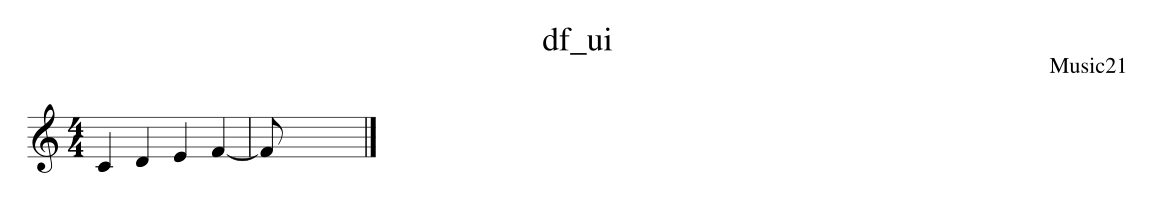

Rendered 1 page(s). Variables available: MEI_LAST, MUSICXML_LAST.


In [52]:
# DataFrame -> symbolic score (via music21) -> render with Verovio
import pandas as pd
from IPython.display import display, SVG
import verovio
from typing import Optional
from music21 import stream, note, chord, meter, metadata, clef


def df_to_music21(
    df: pd.DataFrame,
    *,
    time_signature: str = '4/4',
    unit_quarter_length: float = 1.0,
    piece_title: Optional[str] = None,
    clef_config: str = 'G',           # 'G', 'F', or 'GF'
    split_midi: int | None = 60,      # routing threshold for GF: <= goes to bass, > to treble
) -> stream.Score:
    """
    Convert a DataFrame with columns ['MIDI', 'Global Onset', 'Duration'] into a music21 Score.
    - unit_quarter_length: how many DataFrame time units equal one quarter note (default: 1.0)
    - piece_title: optional title to assign to the resulting score.

    Polyphony: Notes that overlap in time are automatically split into
    separate Voices so that rendering (MusicXML/MEI via Verovio) preserves layers.
    Notes starting at the same onset with the same duration are combined as chords.
    """
    required_cols = {'MIDI', 'Global Onset', 'Duration'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must include columns {required_cols}")

    # Normalize and sort
    df2 = df.copy()
    df2['MIDI'] = df2['MIDI'].astype(int)
    df2['Global Onset'] = df2['Global Onset'].astype(float)
    df2['Duration'] = df2['Duration'].astype(float)
    df2 = df2.sort_values(['Global Onset', 'Duration', 'MIDI']).reset_index(drop=True)

    sc = stream.Score(id='Score')
    if piece_title:
        sc.metadata = metadata.Metadata()
        sc.metadata.title = piece_title

    eps = 1e-6

    # Prepare parts per clef configuration
    parts: list[stream.Part] = []
    route = None  # function to decide which part index to use
    cfg = (clef_config or 'G').upper()
    if cfg not in {'G', 'F', 'GF'}:
        cfg = 'G'
    if cfg == 'G':
        prtG = stream.Part(id='Treble')
        prtG.insert(0, meter.TimeSignature(time_signature))
        prtG.insert(0, clef.TrebleClef())
        parts = [prtG]
        route = lambda midi: 0
    elif cfg == 'F':
        prtF = stream.Part(id='Bass')
        prtF.insert(0, meter.TimeSignature(time_signature))
        prtF.insert(0, clef.BassClef())
        parts = [prtF]
        route = lambda midi: 0
    else:  # 'GF'
        prtG = stream.Part(id='Treble')
        prtG.insert(0, meter.TimeSignature(time_signature))
        prtG.insert(0, clef.TrebleClef())
        prtF = stream.Part(id='Bass')
        prtF.insert(0, meter.TimeSignature(time_signature))
        prtF.insert(0, clef.BassClef())
        parts = [prtG, prtF]
        thr = 60 if split_midi is None else int(split_midi)
        route = lambda midi, thr=thr: 1 if int(midi) <= thr else 0  # 0->Treble, 1->Bass

    # Group events by (onset, duration) -> chord candidates (per part)
    grouped_per_part: list[dict[tuple[float, float], list[int]]] = [dict() for _ in parts]
    onset_idx = int(df2.columns.get_loc('Global Onset'))
    dur_idx = int(df2.columns.get_loc('Duration'))
    midi_idx = int(df2.columns.get_loc('MIDI'))
    for row in df2.itertuples(index=False, name=None):
        midi_val = int(row[midi_idx])
        part_idx = route(midi_val)
        onset_ql = float(row[onset_idx]) / float(unit_quarter_length)
        dur_ql = float(row[dur_idx]) / float(unit_quarter_length)
        if dur_ql <= eps:
            continue
        key = (round(onset_ql, 9), round(dur_ql, 9))
        grouped_per_part[part_idx].setdefault(key, []).append(midi_val)

    # Insert events into each part and finalize measures/voices
    for part, grouped in zip(parts, grouped_per_part):
        events = []
        for (onset_ql, dur_ql), midis in grouped.items():
            midis_sorted = sorted(int(m) for m in midis)
            events.append({
                'onset': float(onset_ql),
                'duration': float(dur_ql),
                'end': float(onset_ql) + float(dur_ql),
                'midis': midis_sorted,
            })
        events.sort(key=lambda e: (e['onset'], -e['duration'], e['midis']))
        for ev in events:
            if len(ev['midis']) == 1:
                n = note.Note(int(ev['midis'][0]))
                n.duration.quarterLength = ev['duration']
                part.insert(ev['onset'], n)
            else:
                ch = chord.Chord([int(m) for m in ev['midis']])
                ch.duration.quarterLength = ev['duration']
                part.insert(ev['onset'], ch)
        sc.append(part)
        try:
            part.makeMeasures(inPlace=True)
        except Exception:
            pass
        try:
            for meas in part.recurse().getElementsByClass(stream.Measure):
                meas.makeVoices(inPlace=True)
        except Exception:
            pass

    try:
        sc.makeNotation(inPlace=True)
    except Exception:
        pass
    return sc


def music21_to_musicxml_string(s: stream.Score) -> str:
    from music21.musicxml.m21ToXml import GeneralObjectExporter
    exporter = GeneralObjectExporter(s)
    xml_bytes = exporter.parse()
    try:
        return xml_bytes.decode('utf-8')
    except AttributeError:
        return str(xml_bytes)


def render_with_verovio_from_musicxml(musicxml_str: str, *, scale: int = 55) -> tuple[str, list[str]]:
    """
    Render MusicXML with Verovio and display SVG pages in the notebook.
    Returns (mei_string, svg_pages)
    """
    tk = verovio.toolkit()
    tk.setOptions({'from': 'musicxml', 'scale': int(scale), 'adjustPageHeight': True})
    tk.loadData(musicxml_str)
    mei_str = tk.getMEI()
    svg_pages = []
    for p in range(1, tk.getPageCount() + 1):
        svg_pages.append(tk.renderToSVG(p))
    for svg in svg_pages:
        display(SVG(svg))
    return mei_str, svg_pages


# Example: render df_ui (created above). If not present, fall back to a tiny demo
target_df_name = 'target_df'
try:
    target_df = df_ui
    target_df_name = 'df_ui'
except NameError:
    target_df = pd.DataFrame({
        'MIDI': [60, 62, 64, 61, 63, 65],
        'Global Onset': [0.0, 1.0, 2.0, 3.0, 3.0, 3.0],
        'Duration': [1.0, 1.0, 1.0, 1.5, 1.5, 1.5],
    })
    target_df_name = 'demo_dataframe'

for name, value in globals().items():
    if value is target_df and name not in {'target_df', 'target_df_name'}:
        target_df_name = name
        break

score = df_to_music21(
    target_df,
    time_signature='4/4',
    unit_quarter_length=1.0,
    piece_title=target_df_name,
    clef_config='G', 
    split_midi=59
)
musicxml_str = music21_to_musicxml_string(score)
mei_str, svg_pages = render_with_verovio_from_musicxml(musicxml_str, scale=55)

# Expose strings for export if needed
MEI_LAST = mei_str
MUSICXML_LAST = musicxml_str
print(f"Rendered {len(svg_pages)} page(s). Variables available: MEI_LAST, MUSICXML_LAST.")


In [ ]:
binary_matrix_df_view
binary_matrix_prototype_view

In [ ]:
import numpy as np
import os
from datetime import datetime

# Directory to save .npy files (change if desired)
OUT_DIR = os.path.join(os.getcwd(), 'exports')
os.makedirs(OUT_DIR, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

saved_paths = []

if 'binary_matrix_df_view' in globals():
    path_df = os.path.join(OUT_DIR, f'binary_matrix_df_view_{timestamp}.npy')
    np.save(path_df, np.asarray(binary_matrix_df_view))
    saved_paths.append(('binary_matrix_df_view', path_df, np.asarray(binary_matrix_df_view).shape))
else:
    print('binary_matrix_df_view is not defined in this session.')

if 'binary_matrix_prototype_view' in globals():
    path_proto = os.path.join(OUT_DIR, f'binary_matrix_prototype_view_{timestamp}.npy')
    np.save(path_proto, np.asarray(binary_matrix_prototype_view))
    saved_paths.append(('binary_matrix_prototype_view', path_proto, np.asarray(binary_matrix_prototype_view).shape))
else:
    print('binary_matrix_prototype_view is not defined in this session.')

if saved_paths:
    print('Saved:')
    for name, path, shape in saved_paths:
        print(f'- {name} {shape} -> {path}')
else:
    print('Nothing saved. Define one of the arrays above and re-run this cell.')
